In [2]:
# # Model 2 — Random Forest

# Random Forest is evaluated as the second machine learning algorithm.

# Based on the Logistic Regression experiment, Class Weight was selected as the preferred approach for handling class imbalance.
# Therefore, Random Forest is trained using Class Weight.a

In [3]:
# Import libraries required for data handling, modelling and evaluation

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [4]:
# Load the SMOTE-balanced training data
# SMOTE has already been applied only to the training dataset

X_train_smote = pd.read_csv("../Data/processed/X_train_smote.csv")
y_train_smote = pd.read_csv("../Data/processed/y_train_smote.csv").squeeze()

# Load the original untouched test data
# The test set must NOT be modified using SMOTE

X_test = pd.read_csv("../Data/processed/X_test.csv")
y_test = pd.read_csv("../Data/processed/y_test.csv").squeeze()

print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train_smote: (396554, 30)
y_train_smote: (396554,)
X_test: (85118, 30)
y_test: (85118,)


In [5]:
# Check the class distribution after SMOTE

print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())

print("\nClass distribution in untouched test data:")
print(y_test.value_counts())

Class distribution after SMOTE:
Class
0    198277
1    198277
Name: count, dtype: int64

Class distribution in untouched test data:
Class
0    84976
1      142
Name: count, dtype: int64


In [6]:
# ## Why Random Forest?

# Random Forest is an ensemble learning algorithm that combines
# multiple decision trees to make predictions.

# It is suitable for this problem because it can model non-linear
# relationships between transaction features and the fraud class.

# The model is trained using the SMOTE-balanced training data while
# the original test data remains untouched.

In [7]:
# Create the Random Forest classifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully.")

Random Forest model created successfully.


In [8]:
# Train the Random Forest model using the SMOTE-balanced training data

model_rf.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [9]:
# Generate class predictions for the untouched test set

y_pred_rf = model_rf.predict(X_test)

# Generate probability predictions for the fraud class
# These probabilities are required for ROC-AUC and PR-AUC

y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [10]:
# Display precision, recall and F1-score for both classes

print("Classification Report — Random Forest with SMOTE")
print(classification_report(y_test, y_pred_rf))

Classification Report — Random Forest with SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.93      0.76      0.84       142

    accuracy                           1.00     85118
   macro avg       0.97      0.88      0.92     85118
weighted avg       1.00      1.00      1.00     85118



In [11]:
# Calculate the main evaluation metrics

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("Precision:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1-score:", round(f1_rf, 4))
print("ROC-AUC:", round(roc_auc_rf, 4))
print("PR-AUC:", round(pr_auc_rf, 4))

Precision: 0.931
Recall: 0.7606
F1-score: 0.8372
ROC-AUC: 0.9687
PR-AUC: 0.8118


In [12]:
# Calculate the confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix — Random Forest with SMOTE")
print(cm_rf)

Confusion Matrix — Random Forest with SMOTE
[[84968     8]
 [   34   108]]


In [13]:
# Store Random Forest results for later comparison

rf_results = {
    "Model": "Random Forest",
    "Technique": "SMOTE",
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-score": f1_rf,
    "ROC-AUC": roc_auc_rf,
    "PR-AUC": pr_auc_rf
}

print(rf_results)

{'Model': 'Random Forest', 'Technique': 'SMOTE', 'Precision': 0.9310344827586207, 'Recall': 0.7605633802816901, 'F1-score': 0.8372093023255814, 'ROC-AUC': np.float64(0.9686626928299223), 'PR-AUC': np.float64(0.811820989697398)}


In [14]:
# Convert the results into a readable table

rf_results_df = pd.DataFrame([rf_results])

rf_results_df

,Model,Technique,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Random Forest,SMOTE,0.931034,0.760563,0.837209,0.968663,0.811821


In [15]:
# Generate fraud probabilities from Random Forest

y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print("Prediction probabilities generated.")
print("First 10 probabilities:")
print(y_prob_rf[:10])

Prediction probabilities generated.
First 10 probabilities:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results = []

for threshold in thresholds:

    y_pred = (y_prob_rf >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_results = pd.DataFrame(results)

print(threshold_results.round(4))

   Threshold  Precision  Recall  F1-Score
0        0.1     0.3409  0.8451    0.4858
1        0.2     0.6860  0.8310    0.7516
2        0.3     0.8099  0.8099    0.8099
3        0.4     0.8740  0.7817    0.8253
4        0.5     0.9310  0.7606    0.8372
5        0.6     0.9455  0.7324    0.8254
6        0.7     0.9717  0.7254    0.8306
7        0.8     0.9697  0.6761    0.7967
8        0.9     0.9667  0.6127    0.7500


Confusion Matrix:
[[84968     8]
 [   34   108]]


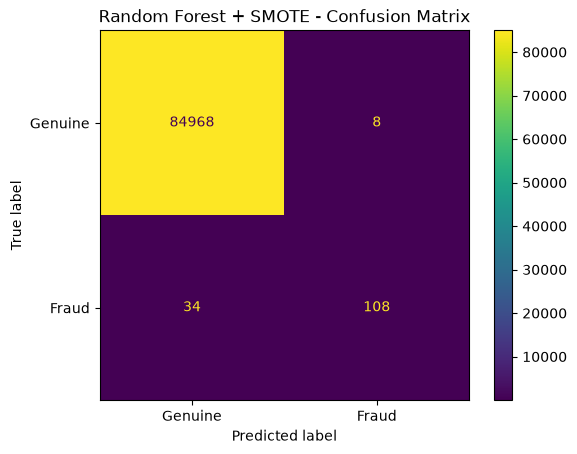

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Final predictions using selected threshold
final_threshold = 0.5

y_pred_final = (y_prob_rf >= final_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
)

disp.plot()
plt.title("Random Forest + SMOTE - Confusion Matrix")
plt.show()

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "Importance": model_rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
   Feature  Importance
14     V14    0.194690
10     V10    0.119203
12     V12    0.100029
4       V4    0.097904
17     V17    0.093915
3       V3    0.066674
11     V11    0.046697
16     V16    0.041235
2       V2    0.038582
9       V9    0.026734
7       V7    0.018519
18     V18    0.014324
8       V8    0.013492
21     V21    0.013371
27     V27    0.012223


In [20]:
import joblib
import os

# Create Models folder if it doesn't exist
os.makedirs("../Models", exist_ok=True)

# Save the trained Random Forest model
joblib.dump(model_rf, "../Models/random_forest_smote.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [21]:
import joblib

final_threshold = 0.5

joblib.dump(
    final_threshold,
    "../Models/random_forest_threshold.pkl"
)

print("Threshold saved successfully!")
print("Final Threshold:", final_threshold)

Threshold saved successfully!
Final Threshold: 0.5


In [22]:
import joblib

# Get the exact feature order used during training
feature_columns = X_train_smote.columns.tolist()

# Save feature order
joblib.dump(
    feature_columns,
    "../Models/feature_columns.pkl"
)

print("Feature columns saved successfully!")
print("Number of features:", len(feature_columns))
print("Features:", feature_columns)

Feature columns saved successfully!
Number of features: 30
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
